# Task 2 – Fraud Detection using Supervised Learning

## Objective

The objective of this project is to develop a supervised machine learning model for fraud detection. Since the provided dataset did not have a fraud column, a new one was created using a rule-based risk point approach. The project includes data preprocessing, handling class imbalance using SMOTE, training classification models, and evaluating their performance.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("cleaned_dataset.csv")

In [3]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Month,WeekendOrder,DiscountUsed,RevenuePerItem
0,ORD200000,04-01-2023,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,January,False,1,570.62
1,ORD200001,23-08-2024,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,August,False,1,151.35
2,ORD200002,27-02-2024,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,February,False,1,550.68
3,ORD200003,15-10-2023,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,October,True,1,273.19
4,ORD200004,08-05-2025,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,May,False,1,626.01


In [4]:
df.shape

(1200, 18)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   str    
 1   Date             1200 non-null   str    
 2   CustomerID       1200 non-null   str    
 3   Product          1200 non-null   str    
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   str    
 7   PaymentMethod    1200 non-null   str    
 8   OrderStatus      1200 non-null   str    
 9   TrackingNumber   1200 non-null   str    
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       1200 non-null   str    
 12  ReferralSource   1200 non-null   str    
 13  TotalPrice       1200 non-null   float64
 14  Month            1200 non-null   str    
 15  WeekendOrder     1200 non-null   bool   
 16  DiscountUsed     1200 non-null   int64  
 17  RevenuePerItem   1200 non

In [6]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice,DiscountUsed,RevenuePerItem
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300,0.742500,356.412750
std,1.407557,197.177146,2.281983,819.856558,0.437439,197.177146
min,1.000000,11.390000,1.000000,11.390000,0.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000,0.000000,186.062500
50%,3.000000,364.210000,5.000000,823.615000,1.000000,364.210000
75%,4.000000,521.570000,7.000000,1578.475000,1.000000,521.570000
max,5.000000,699.930000,10.000000,3456.400000,1.000000,699.930000


In [7]:
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
Month              0
WeekendOrder       0
DiscountUsed       0
RevenuePerItem     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## Synthetic Target Variable

The provided dataset does not contain a fraud column required for supervised learning.

To demonstrate the fraud detection pipeline, a fraud column was created using a rule-based risk scoring method that derives conclusion from a variable that gets its score from certain patterns.

Transactions were considered higher risk when they involved multiple suspicious characteristics such as high transaction value, maximum purchase quantity, absence of discounts, and weekend purchases.

In [9]:
df["RiskScore"] = (
    (df["TotalPrice"] > 3000).astype(int)
    + (df["Quantity"] == 5).astype(int)
    + (df["DiscountUsed"] == 0).astype(int)
    + (df["WeekendOrder"] == True).astype(int)
)

In [10]:
df["Fraud"] = (df["RiskScore"] >= 3).astype(int)

In [11]:
df[["RiskScore","Fraud"]].head(10)

,RiskScore,Fraud
0,1,0
1,0,0
2,1,0
3,1,0
4,0,0
5,0,0
6,0,0
7,1,0
8,1,0
9,0,0


In [12]:
df["Fraud"].value_counts()

Fraud
0    1173
1      27
Name: count, dtype: int64

In [13]:
df.drop(columns=["RiskScore"], inplace=True)

In [14]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Month,WeekendOrder,DiscountUsed,RevenuePerItem,Fraud
0,ORD200000,04-01-2023,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,January,False,1,570.62,0
1,ORD200001,23-08-2024,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,August,False,1,151.35,0
2,ORD200002,27-02-2024,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,February,False,1,550.68,0
3,ORD200003,15-10-2023,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,October,True,1,273.19,0
4,ORD200004,08-05-2025,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,May,False,1,626.01,0


# Encoding Categorical Variables



In [15]:
encoder = LabelEncoder()

categorical_cols = [
    "Product",
    "ShippingAddress",
    "PaymentMethod",
    "OrderStatus",
    "TrackingNumber",
    "CouponCode",
    "ReferralSource",
    "Month"
]

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

In [16]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Month,WeekendOrder,DiscountUsed,RevenuePerItem,Fraud
0,ORD200000,04-01-2023,C72649,3,5,570.62,596,2,4,359,7,2,3,2853.10,4,False,1,570.62,0
1,ORD200001,23-08-2024,C75739,4,2,151.35,512,4,4,1074,3,2,4,302.70,1,False,1,151.35,0
2,ORD200002,27-02-2024,C81728,6,5,550.68,294,1,0,416,8,0,0,2753.40,3,False,1,550.68,0
3,ORD200003,15-10-2023,C33540,0,1,273.19,124,2,3,691,5,2,1,273.19,10,True,1,273.19,0
4,ORD200004,08-05-2025,C81840,5,4,626.01,407,4,1,245,8,2,0,2504.04,8,False,1,626.01,0


## Train-Test Split

In [17]:
X = df.drop(columns=[
    "Fraud",
    "RiskScore",         
    "OrderID",
    "CustomerID",
    "TrackingNumber",
    "Date"
], errors="ignore")

y = df["Fraud"]

In [18]:
print(X.shape)
print(y.shape)

(1200, 14)
(1200,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(960, 14)
(240, 14)
Fraud
0    938
1     22
Name: count, dtype: int64
Fraud
0    235
1      5
Name: count, dtype: int64


SMOTE applied to training data to prevent data leakage into the testing data.

In [21]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [22]:
print(y_train.value_counts())

print()

print(y_train_smote.value_counts())

Fraud
0    938
1     22
Name: count, dtype: int64

Fraud
0    938
1    938
Name: count, dtype: int64


## Logistic Regression Model

In [23]:
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train_smote, y_train_smote)

C:\Users\Naman Chopra\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [26]:
y_pred_log = log_model.predict(X_test)

In [27]:
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("ROC AUC  :", roc_auc_score(y_test, y_pred_log))

Accuracy : 0.9791666666666666
Precision: 0.5
Recall   : 1.0
ROC AUC  : 0.9893617021276595


In [28]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       235
           1       0.50      1.00      0.67         5

    accuracy                           0.98       240
   macro avg       0.75      0.99      0.83       240
weighted avg       0.99      0.98      0.98       240



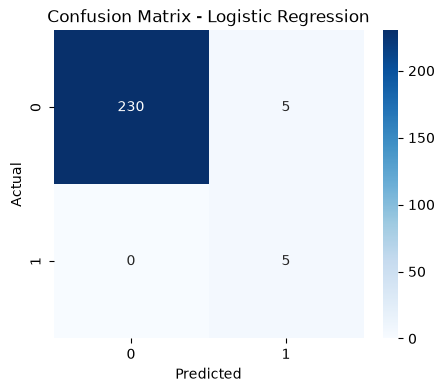

In [29]:
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [31]:
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

rf_model.fit(X_train_smote, y_train_smote)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [32]:
y_pred_rf = rf_model.predict(X_test)

In [33]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_pred_rf))

Accuracy : 0.9958333333333333
Precision: 1.0
Recall   : 0.8
ROC AUC  : 0.9


In [34]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       235
           1       1.00      0.80      0.89         5

    accuracy                           1.00       240
   macro avg       1.00      0.90      0.94       240
weighted avg       1.00      1.00      1.00       240



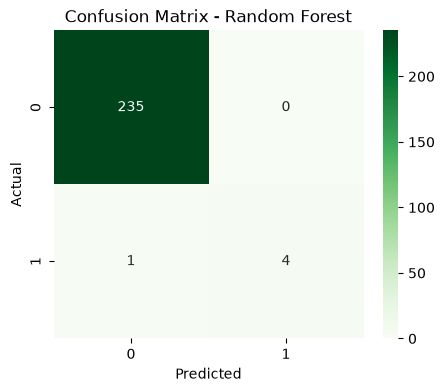

In [35]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [36]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_pred_log),
        roc_auc_score(y_test, y_pred_rf)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,ROC AUC
0,Logistic Regression,0.979167,0.5,1.0,0.989362
1,Random Forest,0.995833,1.0,0.8,0.900000


## Conclusion

Two machine learning models, Logistic Regression and Random Forest were trained on the balanced dataset generated using SMOTE.
Logistic Regression achieved a recall of 100%, successfully detecting all fraudulent transactions, but produced some false positives resulting in a precision of 50%. Random Forest achieved higher overall accuracy (99.58%) and perfect precision (100%), indicating that every predicted fraud transaction was actually a fraud case. However, its recall of 80% indicates that it missed a small number of fraud cases.

Overall, Random Forest achieved the highest overall performance in terms of Accuracy and Precision, while Logistic Regression was more effective at identifying all fraudulent transactions. 